# Alcohol consumption of each Indian state
The data is from NHFS-5 2019 - 2020. The data is collected from people self reporting. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
print("All libs ready")

All libs ready


In [2]:
alc_link= "https://www.findeasy.in/alcohol-consumption-in-india/"
tables = pd.read_html(alc_link)
alc_df = tables[0]
alc_df.columns = alc_df.iloc[0]
alc_df= alc_df.iloc[1:,[1,3]]
alc_df =alc_df.reset_index(drop=True)
alc_df.columns = ["state_name","men %"]
alc_df = alc_df.replace({"Chattishgarh":"Chhattisgarh"})
alc_df

,state_name,men %
0,Andaman & Nicobar Islands,39.1
1,Andhra Pradesh,23.3
2,Arunachal,52.7
3,Assam,25.1
4,Bihar,15.5
5,Chandigarh,18.6
6,Chhattisgarh,34.8
7,D&N,27.8
8,Delhi,21.6
9,Goa,36.9


# OddHouse GII from my github

In [3]:
gii_link = "https://raw.github.com/OddTejas/OddHouse/oddhouse-v2/Data-analysis/Women-discrimination/Data/oddhouse_index.csv"
gii_df = pd.read_csv(gii_link)
gii_df.head()

,state_name,political_inequality,unpaid_labour,workforce_inequality,oddhouse_index
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884
1,Assam,0.796904,0.646149,0.577287,0.673447
2,Bihar,0.397059,1.000000,1.000000,0.799020
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106
4,Delhi,0.517647,0.369919,0.498190,0.461919


In [4]:
gii_df = gii_df.replace({"Himachal":"Himachal Pradesh"})

In [5]:
pd_df = pd.merge(gii_df, alc_df, on="state_name")
pd_df.columns = ["state","political","unpaid_labour","workforce_inequality","GII","alcohol"]


Robust scale was used to scale values without them being skewed by outliers like Gujarat and Telangana.

In [6]:
scaler = RobustScaler()

pd_df["alcohol_scaled"] = scaler.fit_transform(pd_df[["alcohol"]])
pd_df["GII_scaled"] = scaler.fit_transform(pd_df[["GII"]])
pd_df

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471
2,Bihar,0.397059,1.000000,1.000000,0.799020,15.5,-0.648936,3.311529
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484
4,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951
5,Gujarat,0.632992,0.416346,0.559838,0.536392,5.8,-1.680851,0.264188
6,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103
7,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536
8,Jharkhand,0.397059,0.567918,0.878478,0.614485,35,1.425532,1.170320
9,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660


In [7]:
abb = pd.DataFrame({
    "state": [
        "Andhra Pradesh",
        "Assam",
        "Bihar",
        "Chhattisgarh",
        "Delhi",
        "Gujarat",
        "Haryana",
        "Himachal Pradesh",
        "Jharkhand",
        "Karnataka",
        "Kerala",
        "Madhya Pradesh",
        "Maharashtra",
        "Odisha",
        "Punjab",
        "Rajasthan",
        "Tamil Nadu",
        "Telangana",
        "Uttar Pradesh",
        "Uttarakhand",
        "West Bengal"
    ],
    "abbr": [
        "AP",
        "AS",
        "BR",
        "CG",
        "DL",
        "GJ",
        "HR",
        "HP",
        "JH",
        "KA",
        "KL",
        "MP",
        "MH",
        "OD",
        "PJ",
        "RJ",
        "TN",
        "TS",
        "UP",
        "UK",
        "WB"
    ]
})


In [8]:

pd_df = pd_df.merge(abb, on="state", how="left")
pd_df

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled,abbr
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384,AP
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471,AS
2,Bihar,0.397059,1.000000,1.000000,0.799020,15.5,-0.648936,3.311529,BR
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484,CG
4,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951,DL
5,Gujarat,0.632992,0.416346,0.559838,0.536392,5.8,-1.680851,0.264188,GJ
6,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103,HR
7,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536,HP
8,Jharkhand,0.397059,0.567918,0.878478,0.614485,35,1.425532,1.170320,JH
9,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660,KA


## Correlation of the data
Firstly Pearson's R value

In [9]:
r =pd_df["GII"].corr(pd_df["alcohol"])
print(r)

-0.21196577429582114


In [10]:
pd_df["alcohol"] = pd_df["alcohol"].astype(float)
pd_df["GII"] = pd_df["GII"].astype(float)

In [11]:
from scipy.stats import pearsonr

r, p = pearsonr(pd_df["alcohol"], pd_df["GII"])

print(r)
print(p)

-0.21196577429582103
0.3563133928892213


Since OddHouse GII ranks higher score to more inequal state, the correlation is negative. The p valve is however is above the threshold for noise. Thus this analysis does not match the required statsitical siginificance for linear correlation. This could mean the data could be in clusters and need to investigatied not based on simple correlation.

In [12]:
wf =pd_df["workforce_inequality"].corr(pd_df["alcohol"])
up =pd_df["unpaid_labour"].corr(pd_df["alcohol"])
wp =pd_df["political"].corr(pd_df["alcohol"])
print(f"Workforce vs alcohol correlation {wf:.3f}\n Unpaid labour vs alcohol correlation {up:.3f}\n political representation vs alcohol correlation {wp:.3f}")

Workforce vs alcohol correlation -0.241
 Unpaid labour vs alcohol correlation -0.189
 political representation vs alcohol correlation 0.075


 Fact  check with spearman's rank values
 

In [13]:
pd_df["alcohol"].corr(pd_df["GII"], method="spearman")

np.float64(-0.18961038961038962)

# Visuals


TASKS
- create scatterplot
- find clusters

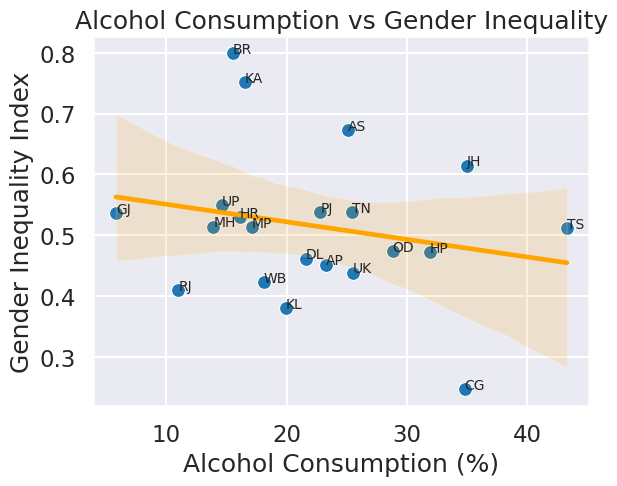

In [14]:
sns.set_style("darkgrid")
figsize=(7,5)
dpi=300
sns.set_context("talk")
# go through every row and get data
#for _, row in pd_df.iterrows():
# sepcial case which throw off the data
#    if row["alcohol"] > 30 or row["alcohol"] < 15:
#take the data and attach it 
#        plt.text(
#            row["GII"],
#            row["alcohol"],
#            row["state"],
#            fontsize=10
#        )
for _, row in pd_df.iterrows():


        plt.text(
            row["alcohol"],
            row["GII"],
            row["abbr"],
            fontsize=10
        )        
#scatterplot
sns.scatterplot(
    data=pd_df,
    x="alcohol",
    y="GII",
    s=100
)
#regression line
sns.regplot(
    data=pd_df,
    x="alcohol",
    y="GII",
    scatter=False,
    color="orange"
)
plt.title("Alcohol Consumption vs Gender Inequality")
plt.xlabel("Alcohol Consumption (%)")
plt.ylabel("Gender Inequality Index")

plt.show()

What might look like downward slope maybe a product of states like Bihar and Gujrat having probation and bringing down the self reports due to social stigma

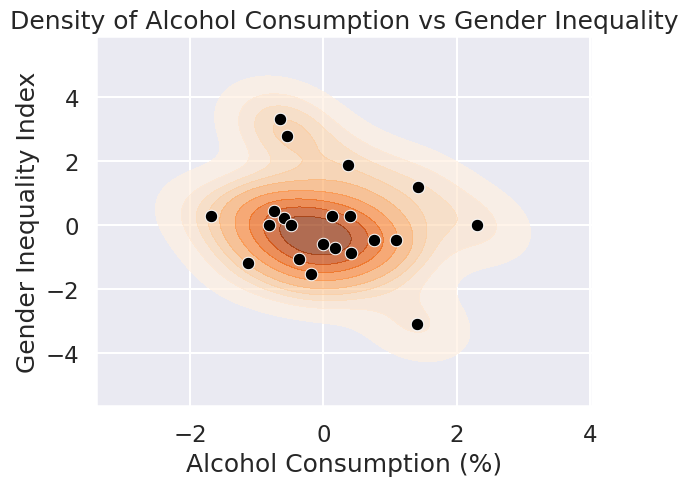

In [15]:
figsize=(7,5)
dpi=300

sns.kdeplot(
    data=pd_df,
    x="alcohol_scaled",
    y="GII_scaled",
    fill=True,
    cmap="Oranges",
    alpha=0.67
)

sns.scatterplot(
    data=pd_df,
    x="alcohol_scaled",
    y="GII_scaled",
    color="black"
)

plt.title("Density of Alcohol Consumption vs Gender Inequality")
plt.xlabel("Alcohol Consumption (%)")
plt.ylabel("Gender Inequality Index")

plt.show()

Let us mathematically make sure the data is not random. Let us perform k mean.

In [16]:
cluster_matrix = pd_df[["alcohol_scaled","GII_scaled"]]

from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

pd_df["cluster"] = kmeans.fit_predict(cluster_matrix)
print(pd_df[["state", "cluster"]])
print(kmeans.cluster_centers_)

               state  cluster
0     Andhra Pradesh        1
1              Assam        0
2              Bihar        0
3       Chhattisgarh        1
4              Delhi        1
5            Gujarat        1
6            Haryana        1
7   Himachal Pradesh        1
8          Jharkhand        0
9          Karnataka        0
10            Kerala        1
11    Madhya Pradesh        1
12       Maharashtra        1
13            Odisha        1
14            Punjab        1
15         Rajasthan        1
16        Tamil Nadu        1
17         Telangana        1
18     Uttar Pradesh        1
19       Uttarakhand        1
20       West Bengal        1
[[ 0.15159574  2.27574509]
 [ 0.04192741 -0.50415681]]


In [17]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_matrix, pd_df["cluster"])

print(score)

0.4567055089392409


The score shows moderate to weak realtion however, upon measuring the cluster centers the data is highly influnced by gender disparity over alcohol consumption. So we cannot say the alcohol and OGI form clusters based on based on gender diffrences of the data set.

In [18]:
pd_df

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled,abbr,cluster
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384,AP,1
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471,AS,0
2,Bihar,0.397059,1.000000,1.000000,0.799020,15.5,-0.648936,3.311529,BR,0
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484,CG,1
4,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951,DL,1
5,Gujarat,0.632992,0.416346,0.559838,0.536392,5.8,-1.680851,0.264188,GJ,1
6,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103,HR,1
7,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536,HP,1
8,Jharkhand,0.397059,0.567918,0.878478,0.614485,35.0,1.425532,1.170320,JH,0
9,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660,KA,0


# Per capita NSDP
The wealth dimension can explain if these findings actually reflect poor vs rich states or the socioeconomic issues

In [19]:
per_cap_link = "https://en.wikipedia.org/wiki/List_of_Indian_states_and_union_territories_by_GDP_per_capita"
per_cap_df = pd.read_html(per_cap_link, storage_options={"User-agent":"Mozilla/5.0"})
per_cap_df = per_cap_df[3]
print(per_cap_df.columns)
per_cap_df = per_cap_df.loc[:,["State/Union territory","2019–20"]]
per_cap_df.columns = ["state","per_cap_NSDP"]
per_cap_df.head()


Index(['Rank[a]', 'State/Union territory', '2004–05', '2009–10', '2010–11',
       '2011–12', '2012–13', '2013–14', '2014–15', '2015–16', '2016–17',
       '2017–18', '2018–19', '2019–20', '2020–21', '2021–22', '2022–23',
       '2023–24'],
      dtype='str')


,state,per_cap_NSDP
0,Goa,435949
1,Sikkim,412627
2,Delhi,355798
3,Chandigarh,330703
4,Telangana,231326


In [20]:
pd_df

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled,abbr,cluster
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384,AP,1
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471,AS,0
2,Bihar,0.397059,1.000000,1.000000,0.799020,15.5,-0.648936,3.311529,BR,0
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484,CG,1
4,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951,DL,1
5,Gujarat,0.632992,0.416346,0.559838,0.536392,5.8,-1.680851,0.264188,GJ,1
6,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103,HR,1
7,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536,HP,1
8,Jharkhand,0.397059,0.567918,0.878478,0.614485,35.0,1.425532,1.170320,JH,0
9,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660,KA,0


In [21]:
print(per_cap_df[["state", "per_cap_NSDP"]].sort_values("per_cap_NSDP"))

                          state  per_cap_NSDP
32                        Bihar         44175
31                Uttar Pradesh         74141
30                    Jharkhand         75016
29                      Manipur         78574
27                        Assam         90123
28                    Meghalaya         95422
26         Jammu and Kashmir[b]        101868
25               Madhya Pradesh        101909
21                       Odisha        104633
22                 Chhattisgarh        106611
23                  West Bengal        110316
20                    Rajasthan        115534
19                      Tripura        121456
24                     Nagaland        122759
18                       Punjab        154385
14               Andhra Pradesh        160341
17            Arunachal Pradesh        182171
15             Himachal Pradesh        186559
12                  Maharashtra        189889
13                  Uttarakhand        190558
16                      Mizoram   

In [22]:
pd_df = pd.merge(pd_df, per_cap_df, on="state")
pd_df[["GII","alcohol","per_cap_NSDP"]].corr()

,GII,alcohol,per_cap_NSDP
GII,1.000000,-0.211966,-0.178397
alcohol,-0.211966,1.000000,-0.002118
per_cap_NSDP,-0.178397,-0.002118,1.000000


There seems to be no significant correlation between these data points. Which could mean that people drink regardless and simple wealth cannot explain the cultral values which effect the oppurtinity and work assigned to women which the index was based on.

# Moving forward
Now that i conformed wealth does not explain the full story we must address the clusters.

In [23]:
pd_df.groupby("cluster")[
    ["GII","alcohol","per_cap_NSDP"]
].mean()

,GII,alcohol,per_cap_NSDP
cluster,,,
0,0.709753,23.025000,107863.750000
1,0.470174,21.994118,173058.941176


In [24]:
pd_df.groupby("cluster")[
    ["GII","alcohol","per_cap_NSDP"]
].median()

,GII,alcohol,per_cap_NSDP
cluster,,,
0,0.712754,20.8,82569.5
1,0.473860,21.6,186559.0


In [25]:
cluster_names = {
    0: "Cluster A",
    1: "Cluster B"
}

pd_df["clusters"] = pd_df["cluster"].map(cluster_names)

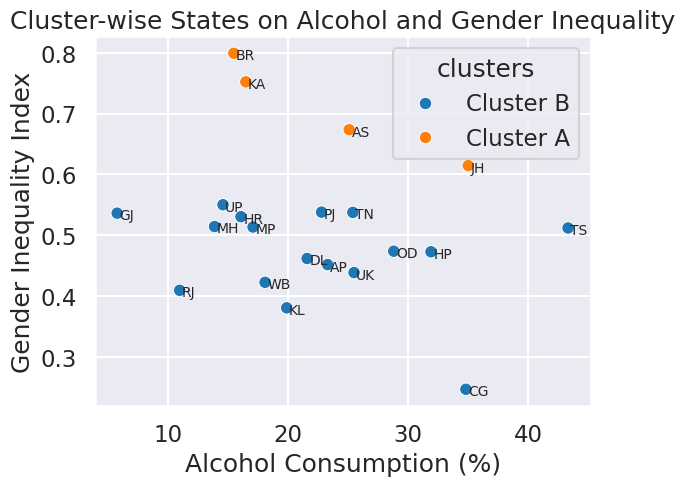

In [35]:


sns.set_context("talk")
figsize=(7,5)
dpi=300
sns.scatterplot(
    data=pd_df,
    x="alcohol",
    y="GII",
    hue="clusters"
)

for _, row in pd_df.iterrows():


        plt.text(
            row["alcohol"]+0.18,
            row["GII"]-0.01,
            row["abbr"],
            fontsize=10
        )        

plt.title("Cluster-wise States on Alcohol and Gender Inequality")
plt.xlabel("Alcohol Consumption (%)")
plt.ylabel("Gender Inequality Index")
plt.show()


# dry states
lets check the relationship without dry states.

In [27]:
dry_states = ["Gujarat", "Bihar"]

pd_nodry = pd_df[~pd_df["state"].isin(dry_states)].reset_index(drop = True)
pd_nodry

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled,abbr,cluster,per_cap_NSDP,clusters
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384,AP,1,160341,Cluster B
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471,AS,0,90123,Cluster A
2,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484,CG,1,106611,Cluster B
3,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951,DL,1,355798,Cluster B
4,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103,HR,1,232530,Cluster B
5,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536,HP,1,186559,Cluster B
6,Jharkhand,0.397059,0.567918,0.878478,0.614485,35.0,1.425532,1.170320,JH,0,75016,Cluster A
7,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660,KA,0,222141,Cluster A
8,Kerala,0.575953,0.566668,0.000000,0.380874,19.9,-0.180851,-1.540338,KL,1,208879,Cluster B
9,Madhya Pradesh,0.575953,0.194215,0.770703,0.513624,17.1,-0.478723,0.000000,MP,1,101909,Cluster B


In [28]:
pd_nodry[['alcohol','GII']].corr()

,alcohol,GII
alcohol,1.000000,-0.125167
GII,-0.125167,1.000000


The data shows correlations decreases when dry states are removed which shocked me

In [29]:
pd_df

,state,political,unpaid_labour,workforce_inequality,GII,alcohol,alcohol_scaled,GII_scaled,abbr,cluster,per_cap_NSDP,clusters
0,Andhra Pradesh,0.575953,0.475329,0.304370,0.451884,23.3,0.180851,-0.716384,AP,1,160341,Cluster B
1,Assam,0.796904,0.646149,0.577287,0.673447,25.1,0.372340,1.854471,AS,0,90123,Cluster A
2,Bihar,0.397059,1.000000,1.000000,0.799020,15.5,-0.648936,3.311529,BR,0,44175,Cluster A
3,Chhattisgarh,0.000000,0.285841,0.455477,0.247106,34.8,1.404255,-3.092484,CG,1,106611,Cluster B
4,Delhi,0.517647,0.369919,0.498190,0.461919,21.6,0.000000,-0.599951,DL,1,355798,Cluster B
5,Gujarat,0.632992,0.416346,0.559838,0.536392,5.8,-1.680851,0.264188,GJ,1,212428,Cluster B
6,Haryana,0.517647,0.455774,0.618411,0.530611,16.1,-0.585106,0.197103,HR,1,232530,Cluster B
7,Himachal Pradesh,1.000000,0.000000,0.418957,0.472986,31.9,1.095745,-0.471536,HP,1,186559,Cluster B
8,Jharkhand,0.397059,0.567918,0.878478,0.614485,35.0,1.425532,1.170320,JH,0,75016,Cluster A
9,Karnataka,0.849265,0.812932,0.593987,0.752061,16.5,-0.542553,2.766660,KA,0,222141,Cluster A
